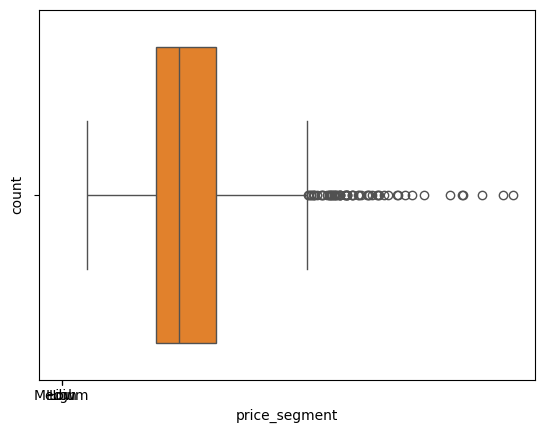

<Axes: xlabel='GrLivArea', ylabel='Count'>

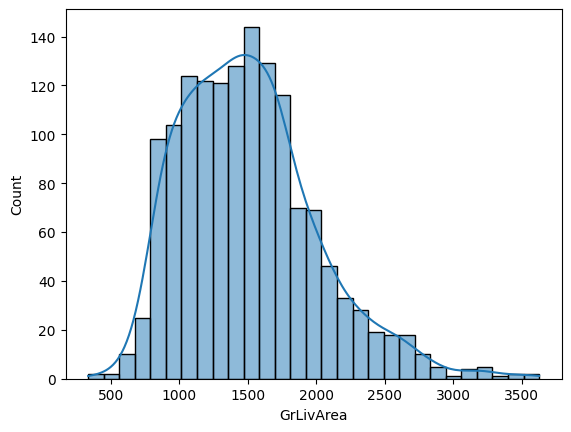

In [13]:
## Day -10
## Hour 1 - Block 1
import pandas as pd
df = pd.read_csv('house_price_v4_final.csv')
df.head()

# Univariate Analysis
df['SalePrice'].describe()

## Visualization

import matplotlib.pyplot as plt
# plt.hist(df['SalePrice'], bins=20)
# plt.xlabel('Sale Price')
# plt.ylabel('Frequency')
# plt.title('Distribution of Sale Prices')
# plt.show()

import seaborn as sns

# 2 Categorical Columns
df['Neighborhood'].value_counts()
sns.countplot(x='price_segment', data=df)

## Outlier Detection
sns.boxplot(x=df['SalePrice'])
plt.show()

## Minitask
df['GrLivArea'].describe()
sns.histplot(df['GrLivArea'], kde=True)

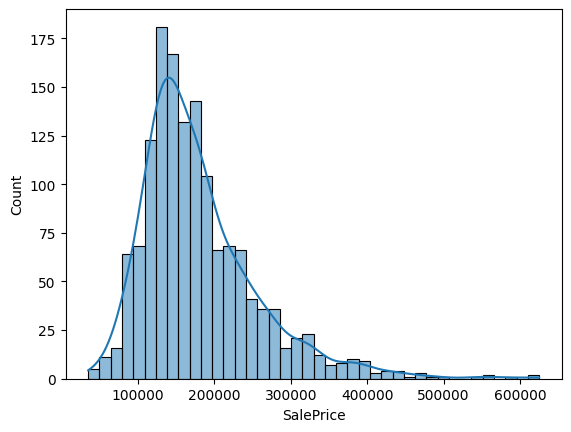

<Axes: xlabel='SalePrice_log', ylabel='Count'>

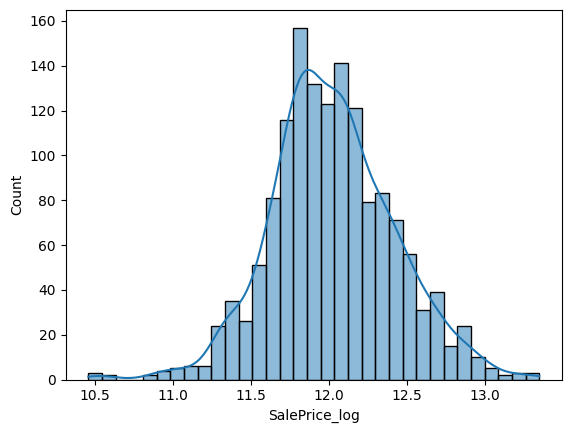

In [21]:
## Block 2 - Hour 1
df['SalePrice'].skew()
sns.histplot(df['SalePrice'], kde=True)
plt.show()

## Skewness has to be fixed and we can do that by applying log transformation
import numpy as np
df['SalePrice_log'] = np.log1p(df['SalePrice'])
df['SalePrice_log'].skew()
sns.histplot(df['SalePrice_log'], kde=True)

0.8351923886551447


<Axes: xlabel='GrLivArea', ylabel='Count'>

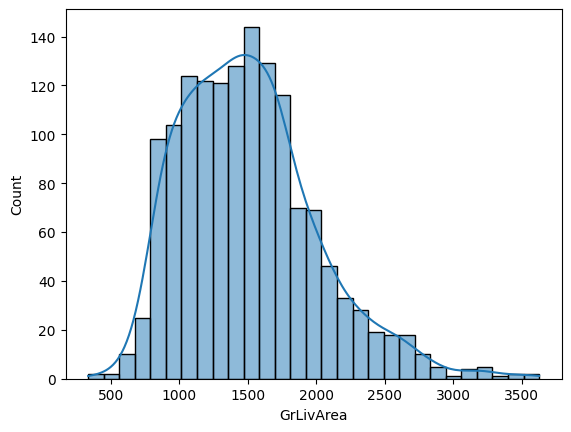

In [23]:
print(df['GrLivArea'].skew())
sns.histplot(df['GrLivArea'], kde=True)

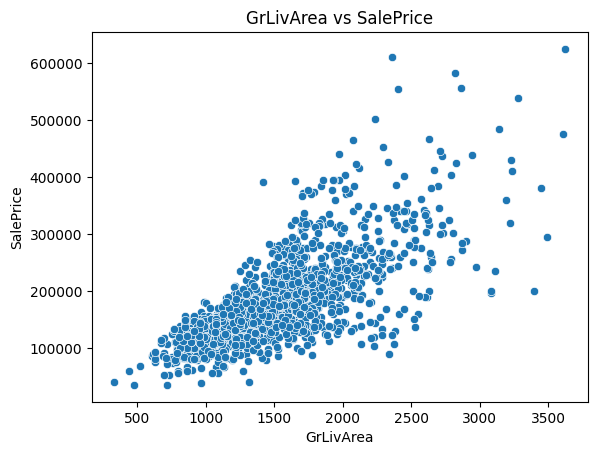

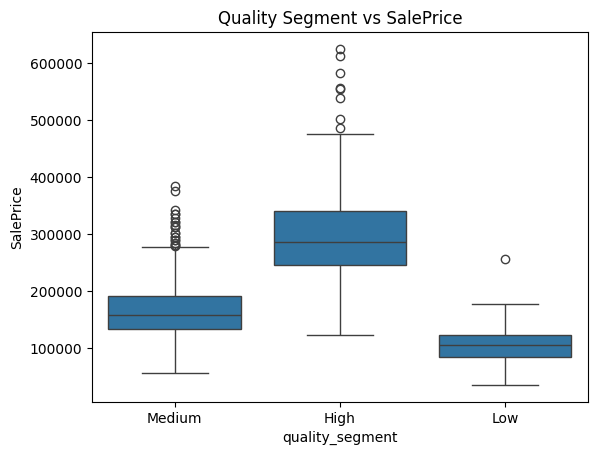

In [25]:
## hour 2 - block 1
## Bivariate Analysis
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('GrLivArea vs SalePrice')
plt.show()

## Categorical vs Numerical
sns.boxplot(x='quality_segment', y='SalePrice', data=df)
plt.title('Quality Segment vs SalePrice')
plt.show()

<Axes: xlabel='TotalSF', ylabel='SalePrice'>

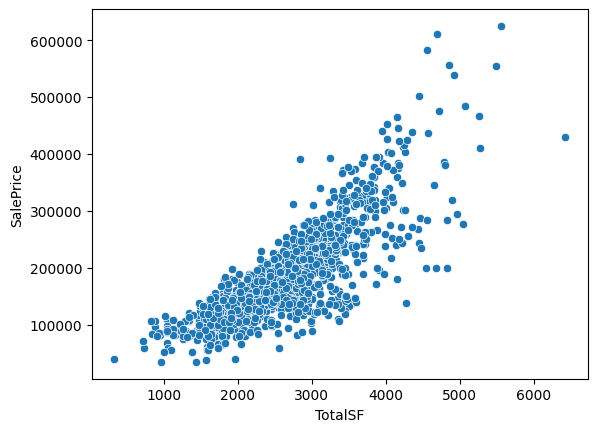

In [28]:
## Categorical vs Categorical
pd.crosstab(df['price_segment'], df['quality_segment'])

## 4. Correlation
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.scatterplot(x='TotalSF', y='SalePrice', data=df)

In [29]:
## hour 2 - block 2
# Correlation Deep Dive + Insights
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.head(10))

SalePrice                 1.000000
SalePrice_log             0.954610
overall_score             0.864957
TotalSF                   0.821091
OverallQual               0.800858
Neighborhood_Avg_Price    0.744223
GrLivArea                 0.720516
Luxury                    0.715710
price_diff                0.667931
GarageCars                0.649256
Name: SalePrice, dtype: float64


Index(['SalePrice', 'SalePrice_log', 'overall_score', 'TotalSF', 'OverallQual',
       'Neighborhood_Avg_Price', 'GrLivArea', 'Luxury', 'price_diff',
       'GarageCars'],
      dtype='object')


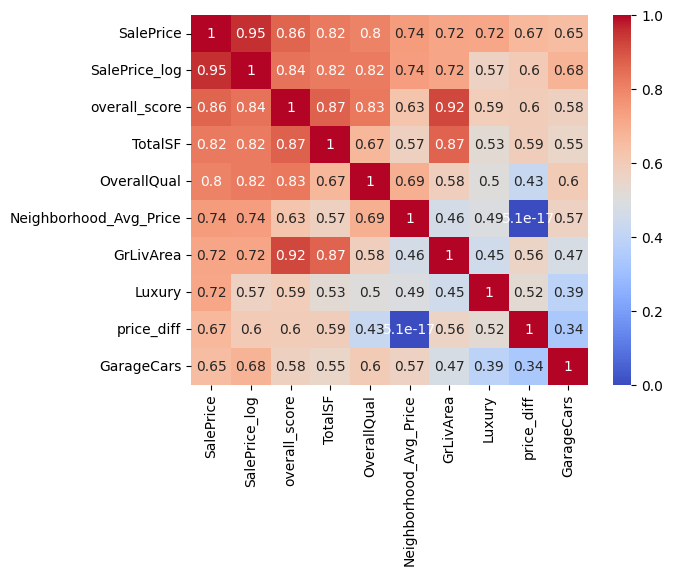

In [ ]:
## Heatmap
top_cols = corr.head(10).index
print(top_cols)
sns.heatmap(df[top_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

<Axes: >

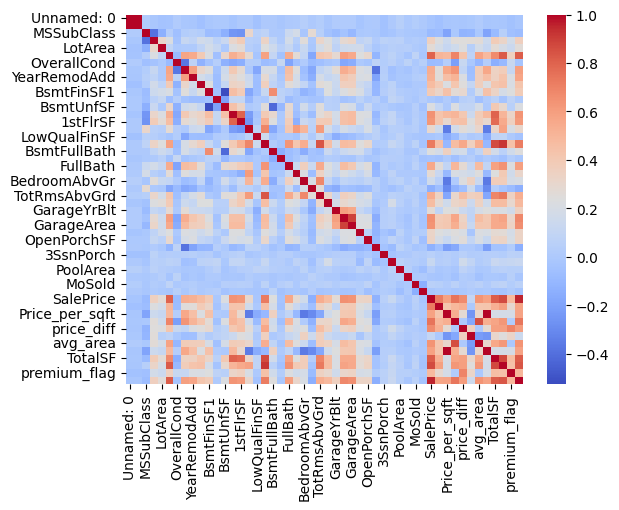

In [34]:
## Multicollinearity
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

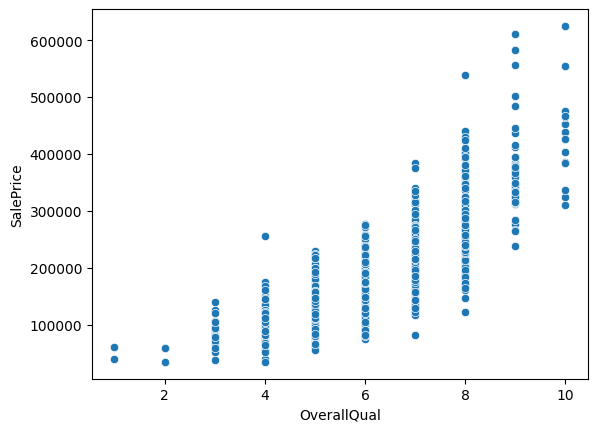

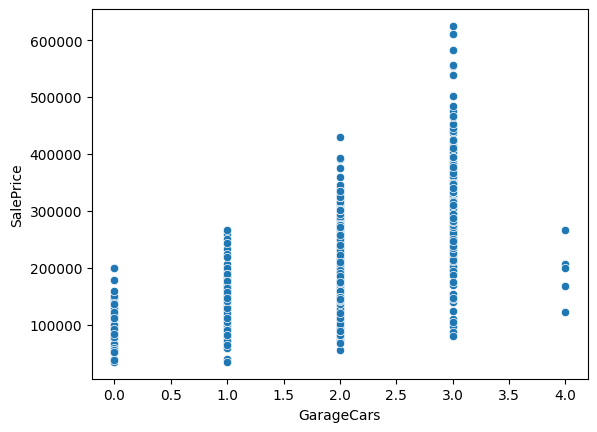

In [37]:
sns.scatterplot(x='OverallQual', y='SalePrice', data=df)
plt.show()
sns.scatterplot(x='GarageCars', y='SalePrice', data=df)
plt.show()

In [40]:
## HOur 3 - Block 1
## Multivariate Analysis
## how area_segment and quality_segment together impact the sale price
df.groupby(['area_segment','quality_segment'])['SalePrice'].mean()

area_segment  quality_segment
Large         High               323125.682927
              Low                122277.777778
              Medium             202088.735484
Medium        High               249602.741379
              Low                119540.038462
              Medium             167315.935484
Small         High               179633.333333
              Low                 97861.707547
              Medium             131655.206897
Name: SalePrice, dtype: float64

In [41]:
## 2. Pivot Table
pd.pivot_table(
    df,
    values='SalePrice',
    index='area_segment',
    columns='quality_segment',
    aggfunc='mean'
)

quality_segment,High,Low,Medium
area_segment,,,
Large,323125.682927,122277.777778,202088.735484
Medium,249602.741379,119540.038462,167315.935484
Small,179633.333333,97861.707547,131655.206897


In [42]:
## Add Third Dimension
pd.pivot_table(
    df,
    values='SalePrice',
    index='area_segment',
    columns=['quality_segment','price_segment'],
    aggfunc='mean'
)

quality_segment           High                                Low  \
price_segment             High       Low         Medium      High   
area_segment                                                        
Large            329481.721519  122000.0  162500.000000       NaN   
Medium           256101.113208       NaN  180720.000000  256000.0   
Small                      NaN       NaN  179633.333333       NaN   

quality_segment                                  Medium                 \
price_segment              Low    Medium           High            Low   
area_segment                                                             
Large            114200.000000  150550.0  235819.625698  126955.902439   
Medium           106478.142857  154000.0  216080.292683  119035.950000   
Small             95349.910891  148600.0  198875.000000  116677.940426   

quality_segment                 
price_segment           Medium  
area_segment                    
Large            169228.922222  
Medium           166750.464730  
Small            153908.186567

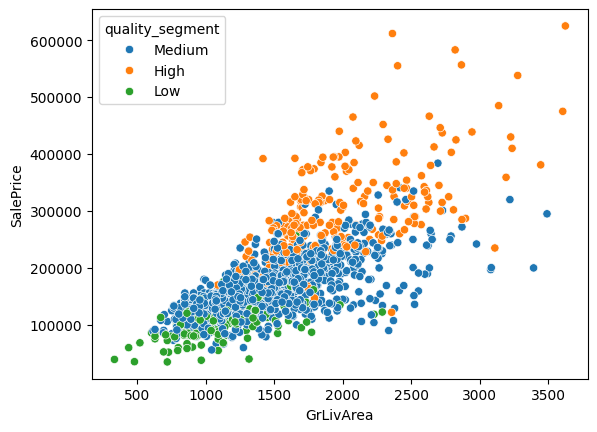

In [43]:
## Visualize Multivariate Analysis
sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    hue='quality_segment',
    data=df
)
plt.show()

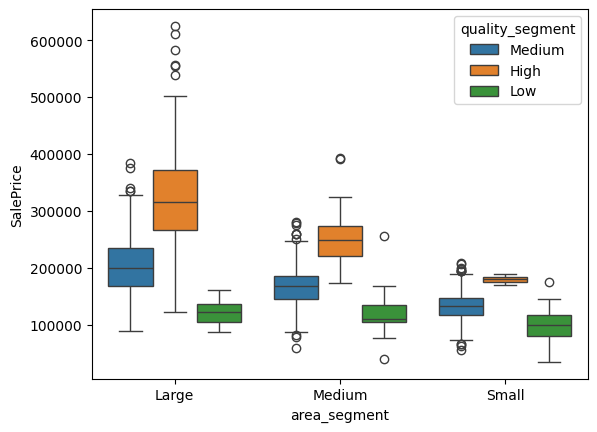

In [44]:
sns.boxplot(
    x='area_segment',
    y='SalePrice',
    hue='quality_segment',
    data=df
)
plt.show()

In [45]:
pd.pivot_table(
    df,
    values='price_per_sqft',
    index='quality_segment',
    columns='area_segment',
    aggfunc='mean'
)

area_segment,Large,Medium,Small
quality_segment,,,
High,149.280945,163.828547,151.981619
Low,65.353086,82.672726,105.750439
Medium,102.033198,115.601752,130.032018


In [ ]:
## Hour 4
## EDA Story telling
## Block 1
df.groupby('quality_segment')['SalePrice'].mean()
## Insights - Higher the quality segment , likelihood of higher
## prices are more - highest quality house is 192.27 %%!higher
# Than low quality houses

## Area vs Price
df.groupby('area_segment')['SalePrice'].mean()
# Large house cost 117118 more than small house on average

# Premium Flag
df['premium_flag'].value_counts()
(639/817)*100
# Premium houses are 78.3% more expensive than non-premium houses on average

# Five Insights
# 1.Quality Segment is a strong indicator of Sale Price, 
# with higher quality segments commanding
# significantly higher prices. 
# The highest quality segment is on average 192.27% more 
# expensive than the lowest quality segment.
# Large house cost 117118 more than small house on average

# 2. Certain neighborhoods have higher average sale prices, 
# indicating that location is a key factor 
# in determining property value.

# 3. Premium houses are 78.3% more expensive than non-premium houses on average, suggesting that premium features and amenities 
# significantly increase a property's value.




78.21297429620563

<Axes: xlabel='quality_segment', ylabel='SalePrice'>

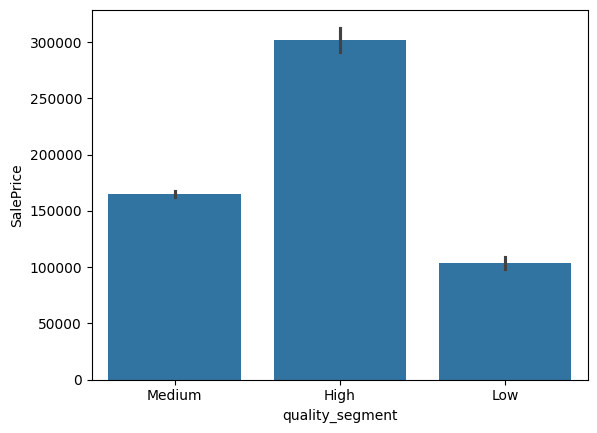

In [ ]:
## Block 3
## Support insights with visualizations
sns.barplot(x='quality_segment', y='SalePrice', data=df)
## Insights - price increases with quality


## Final story
## Price increases with quality.
## more area indicates generally higher price
## Certain neighborhood are more expensive than others on avergae price
## More housing units are there in middle segment
## than low and high.


In [ ]:
## Hour 5
## Provide key factors driving housing prices
## and actionable insights 

## Block 2
key_cols = [
    'SalePrice',
    'GrLivArea',
    'OverallQual',
    'price_per_sqft',
    'area_segment',
    'quality_segment'
]

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

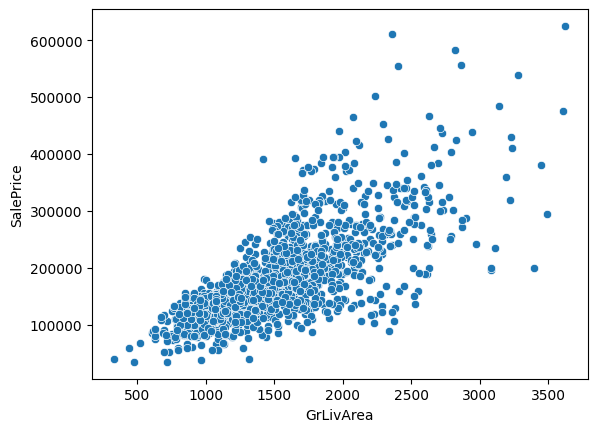

In [ ]:
## Provide four core insights
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
## Insights - Larger area have generally higher price


<Axes: xlabel='quality_segment', ylabel='SalePrice'>

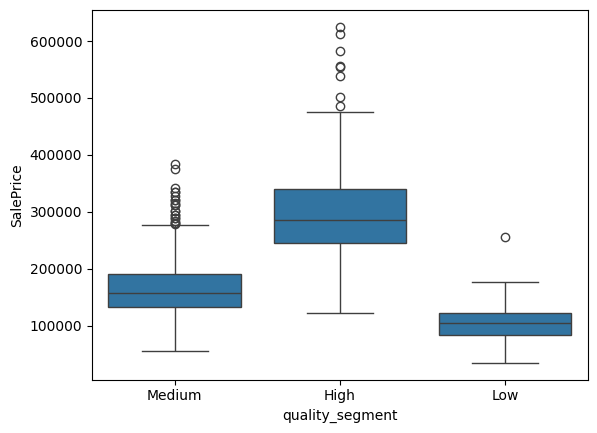

In [ ]:
## Quality Impact
sns.boxplot(x='quality_segment', y='SalePrice', data=df)
## Insights 2 -
## higher quality segment have higher median price 


<Axes: xlabel='quality_segment', ylabel='price_per_sqft'>

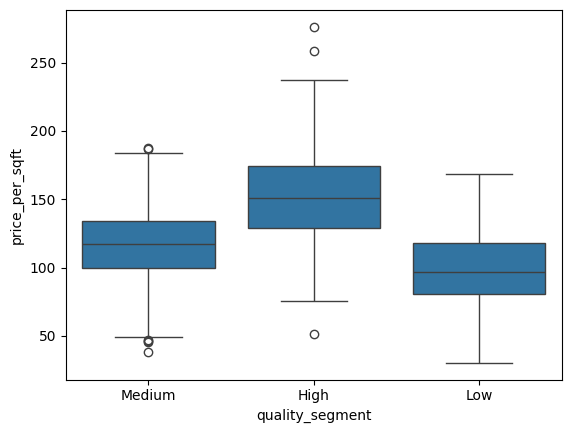

In [ ]:
## Insights 3 - price efficiency
sns.boxplot(x='quality_segment', y='price_per_sqft', data=df)

## higher quality houses hhave higher price per sqft


In [58]:
## Price  vs area segment
df.groupby('area_segment')['SalePrice'].mean()

area_segment
Large     241699.006211
Medium    174565.342916
Small     124580.769547
Name: SalePrice, dtype: float64

In [ ]:
# Recommendation:
# Builders should focus on improving quality and optimizing 
# space utilization
# to maximize property value and target premium segments.

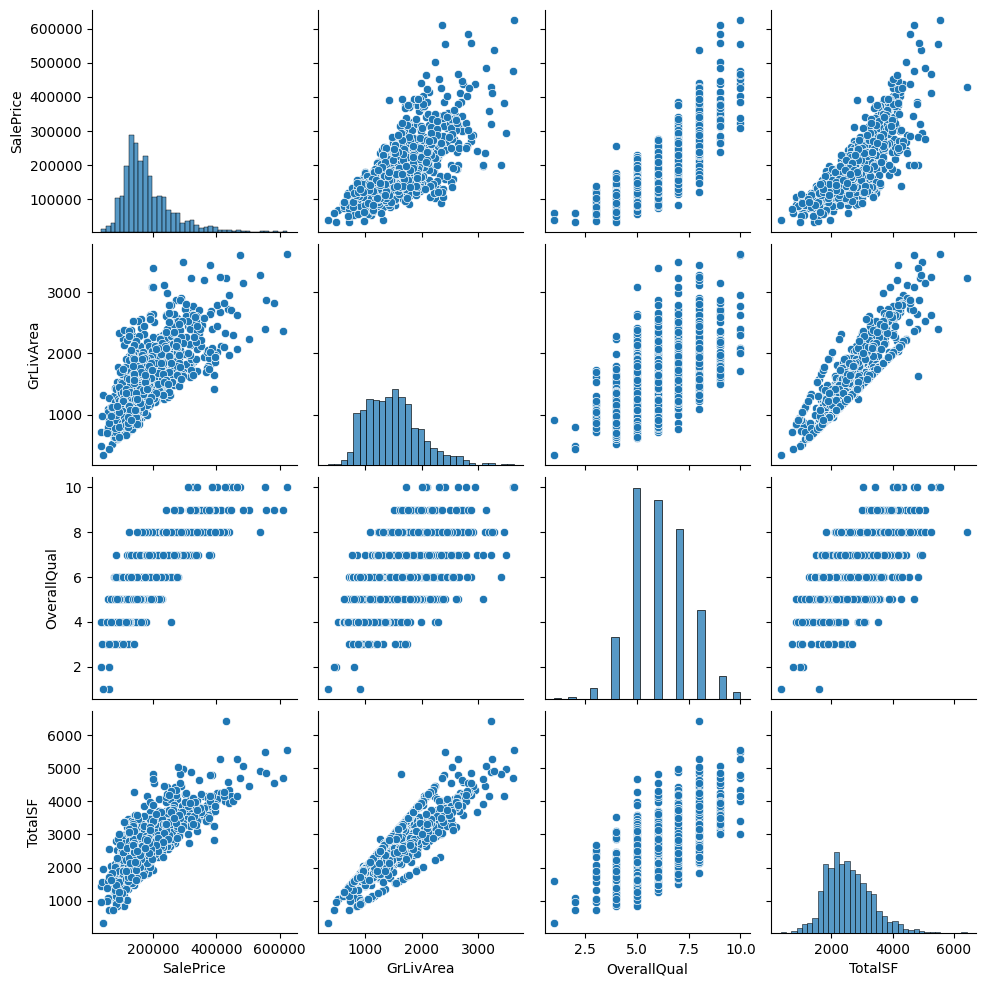

In [61]:
## Hour 6
## Pairplot
import seaborn as sns

cols = ['SalePrice','GrLivArea','OverallQual','TotalSF']

sns.pairplot(df[cols])
plt.show()

KeyError: 'quality_segment'

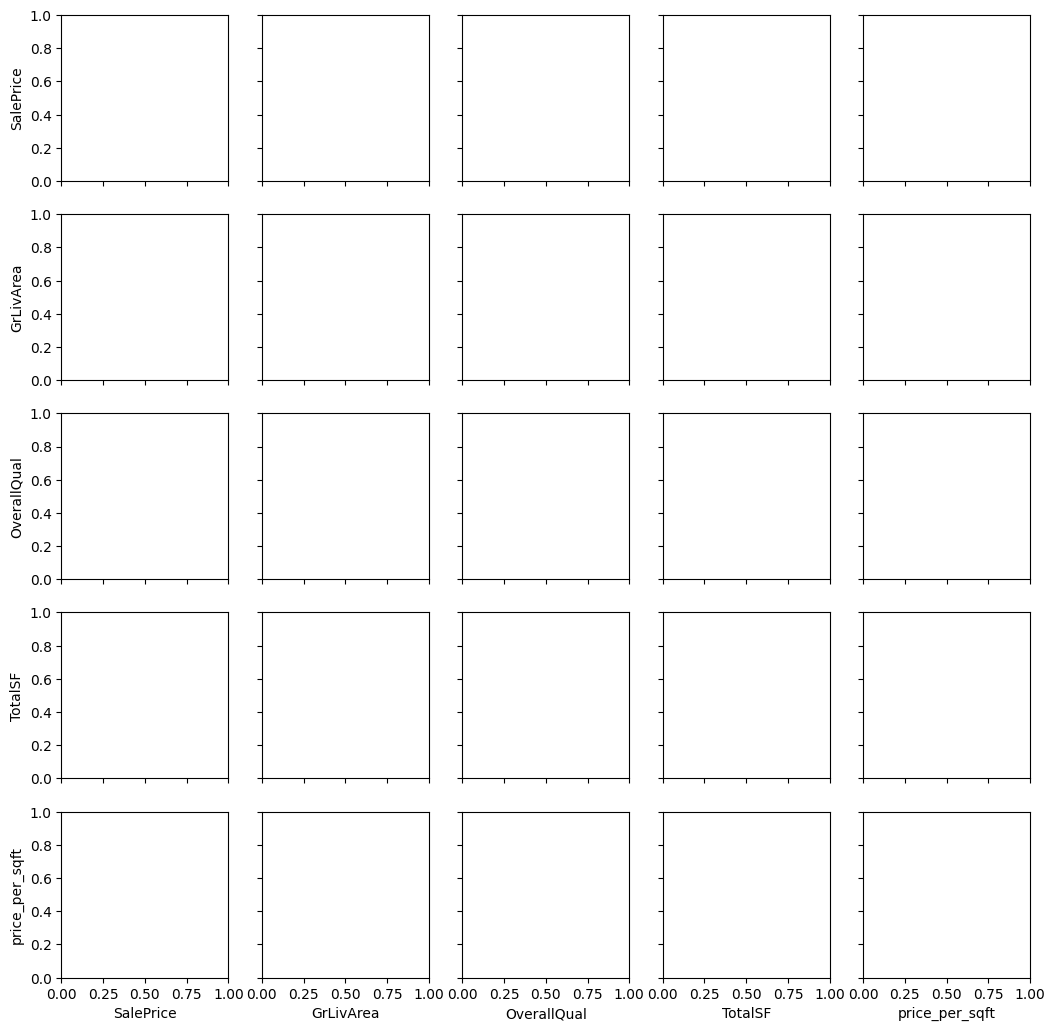

In [73]:
## Block 2
## Pairplot with hue
sns.pairplot(df[cols], hue='quality_segment')
plt.show()
df['quality_segment']

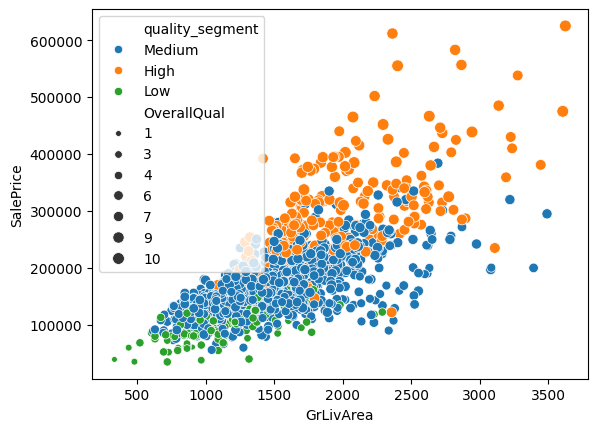

In [ ]:
 ## Block -3 
 #  Multivariate Scatterplot
sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    hue='quality_segment',
    size='OverallQual',
    data=df
)
plt.show()

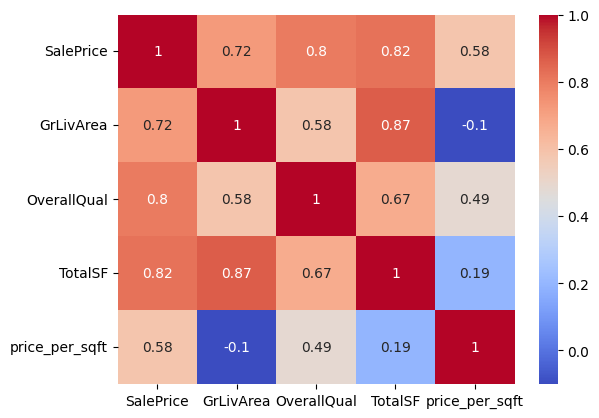

In [67]:
cols = ['SalePrice','GrLivArea','OverallQual','TotalSF','price_per_sqft']

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

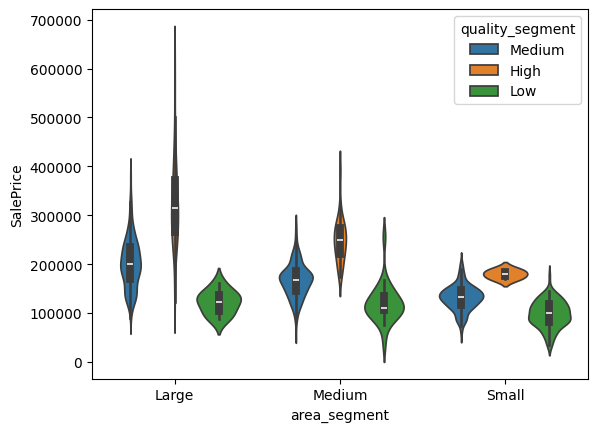

In [68]:
## Violin Multivariate
sns.violinplot(
    x='area_segment',
    y='SalePrice',
    hue='quality_segment',
    data=df
)
plt.show()

In [75]:
## Hour 7
## Block 1 - Leet Code
s1='listen'
s2='silent'
from collections import Counter
print(Counter(s1) == Counter(s2))

True


In [ ]:
## block 2
# Longest common prefix
lst=["flower","flow","flight"]
prefix = lst[0]

for word in lst[1:]:
    while not word.startswith(prefix):
        prefix = prefix[:-1]
        if not prefix:
            break
print(prefix)

fl


In [ ]:
## Block 3
## Valid parentheses
# "()[]{}" → True  
# "(]" → False
s = "()[]{}"
def is_valid_parentheses(s):
    stack = []
    mapping = {')': '(', '}': '{', ']': '['}
    
    for char in s:
        if char in mapping.values():
            stack.append(char)
        elif char in mapping.keys():
            if not stack or stack[-1] != mapping[char]:
                return False
            stack.pop()
        else:
            return False
            
    return len(stack) == 0

## Hour 8
1. Title
House Price Analysis - EDA Report

2. Objective
To analyse factors affecting house prices and extract meaningful
insights

3. Dataset Overview
Dataset containes housing featues like area,quality,location
and price

Key Insights
1. House prices increases with living area, showing strong
relation
2. Higher quality houses consistently have higher median prices.
3. Price per square foot increases with quality,
indicating premium valuation
4. Large and high-quality houses dominate the premium price segment.


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

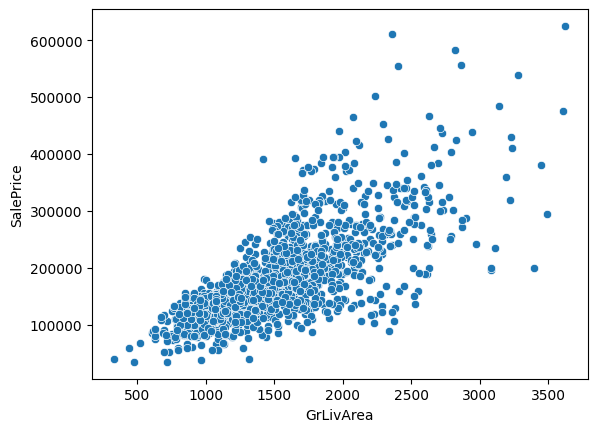

In [80]:
## Add suppporting visualizations
# 1. Insight 1
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)

<Axes: xlabel='quality_segment', ylabel='SalePrice'>

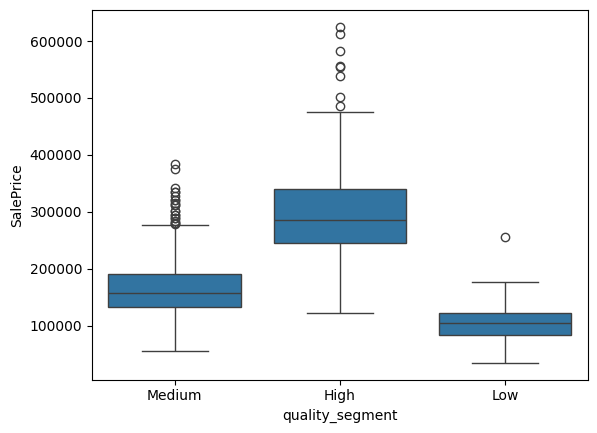

In [81]:
# 2. Insight 2
sns.boxplot(x='quality_segment', y='SalePrice', data=df)

<Axes: xlabel='quality_segment', ylabel='price_per_sqft'>

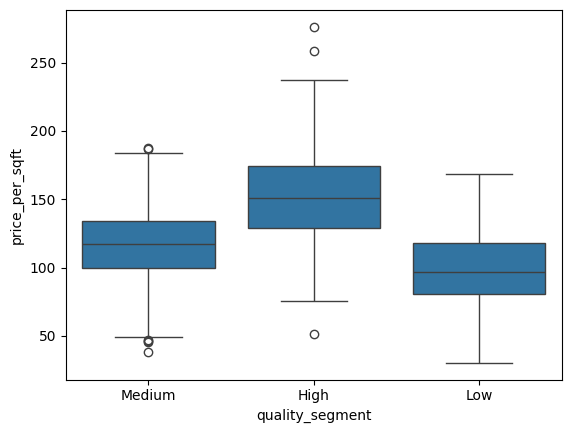

In [82]:
## Insight 3
sns.boxplot(x='quality_segment', y='price_per_sqft', data=df)


<Axes: xlabel='area_segment', ylabel='SalePrice'>

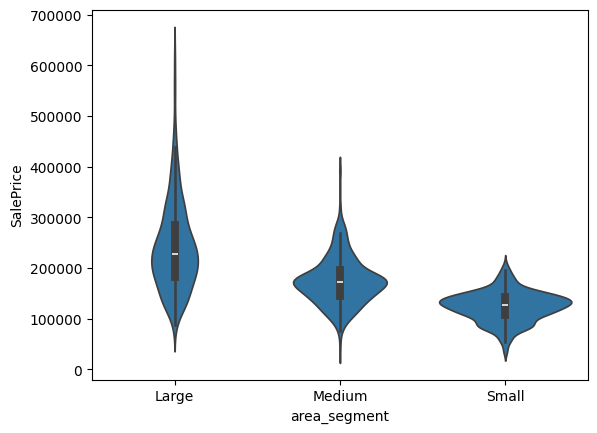

In [83]:
sns.violinplot(x='area_segment', y='SalePrice', data=df)

## Final Story
The analysis indicates that house prices are primarily driven by
living area and construction quality. Larger and high-quality houses
consistently fall into premium segments, while smaller and lower-quality
houses remain in lower price ranges. Additionally, price efficiency
increases with quality, suggesting that buyers are willing to pay more
for better-built homes. The market shows clear segmentation with
balanced distribution across price categories.

Business Recommendation
Builder should focus on improving quality and optimising space to maximise property value and target premium segment.